# Why GRPO RL did not improve SURDS accuracy — a diagnosis

**Run analysed.** `A_grpo_v3` L2-direct (SLURM 1064116): Qwen3-VL-8B-**Thinking** SFT
(SURDS+Mulberry, greedy pass@1 baseline **0.6583**), GRPO with LoRA r128, 16
generations/prompt, `beta=0.01`, `lr 5e-6`, reward = `1.0·binary + 0.20·Gaussian-dense`,
one full epoch (710 steps) on the L2 "headroom" difficulty band.

**Symptom.** Training was perfectly stable (bounded grad-norm, length held ~600, entropy
stable) yet **binary accuracy stayed flat (+0.003 over the epoch)** while the policy's
KL-divergence from the SFT reference grew **40×**. The same flat result held across every
prior config (beta 0/0.005/0.01, lr 1e-6/1e-5/5e-6, binary/dense/combined reward, bands L1/L2).

## TL;DR — the flat curve is an **aggregation artifact**, not a broken pipeline
1. **GRPO *did* work where capability exists:** `depth` **+8.3 pp** and `distance` **+4.7 pp** improved.
2. **It is flat on `yaw` (≈46 % of the data)**, the one family with **no perceptual capability to
   sharpen**: `yaw` is an **axis mirror-flip** ambiguity (e.g. gold E→pred W 50 %, NE→SE 65 %) — the
   model gets the orientation *axis* but the wrong *sign*. This dominates the average.
3. **`xy2d` is NOT the random failure first reported.** In the correct **pixel** frame, wrong points
   sit a median **1.98× tolerance** out (not 8.8×) and **~64 % of rollouts land within 2× tol** — a
   *near-miss* distribution. Student greedy ≈ **30 %**, the 235 B teacher is **76 %**, and the Gaussian
   dense reward (σ≈50 px) is **active**. So `xy2d` is a **consolidation** target, not a capability gap.
   *(The earlier "random / median 8.8× tol / reward inactive" read was a coordinate-FRAME bug — 0–1000
   norm prediction compared against ~1600 px gold; see repo `CLAUDE.md` "SURDS xy2d coordinate frames".)*
4. **RL only sharpens capability the model already has** (pass@16 ≫ pass@1 = sampling efficiency,
   not new capability). The 40× KL with flat *yaw* accuracy = the policy reshuffled a wrong perceptual
   prior; it did not learn to see.
5. So "improve accuracy" splits into **(A) consolidation** on depth/distance/fb **and `xy2d`**
   (RL/RFT/teacher-distillation helps) and **(B) a perception capability gap** on **`yaw`** alone
   (needs grounding data / base / tool-use — *not* reward or RL tuning).

*Evidence below is computed from the run's own 64 MB per-rollout `completions.jsonl` and
`logging.jsonl`, consolidated by `_prep_grpo_accuracy_stall_data.py`. Method leaves: level-4
research-subagent (T1 rollouts, T3 theory, T4 calibration, T5 solutions, T6 red-team).*

In [1]:
import json
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# notebook runs from notebooks/ ; plotstyle lives in ../research/eval
EVAL_DIR = (Path.cwd().parent / 'research' / 'eval').resolve()
sys.path.insert(0, str(EVAL_DIR))
import plotstyle as ps
ps.set_pub_style()

FIG_DIR = Path('figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA = json.loads((Path('data') / 'grpo_accuracy_stall_diagnosis_data.json').read_text())

META = DATA['meta']
TPL_ORDER = ps.TEMPLATE_ORDER                       # lr, distance, fb, yaw, xy2d, depth
def tname(t): return ps.full_template(t)            # spelled-out names, per house style
COUNTS = META['template_counts']
N_TOT = sum(COUNTS.values())
print('run        :', META['run'])
print('config     :', META['config'])
print('greedy SFT baseline (held-out pass@1):', META['greedy_sft_baseline'])
print('overall hot rollout acc (temp 1.0)   :', round(META['overall_hot_acc'], 4))
print('rollouts by family:', COUNTS)
pd.set_option('display.max_colwidth', 160)

run        : A_grpo_v3 L2-direct (job 1064116)
config     : GRPO, Qwen3-VL-8B-Thinking SFT, LoRA r128, 16 gen/prompt, beta=0.01, lr 5e-6, reward=1*binary+0.20*Gaussian-dense, L2 band 710 steps
greedy SFT baseline (held-out pass@1): 0.6583
overall hot rollout acc (temp 1.0)   : 0.3521
rollouts by family: {'yaw': 8784, 'distance': 880, 'fb': 4864, 'depth': 2848, 'lr': 368, 'xy2d': 688}


## 1 · The aggregate is flat — but per family it is **not**

Binning every rollout into five equal step-buckets across the epoch and scoring binary
correctness per family. `depth` and `distance` climb; `yaw` and `xy2d` are flat; `lr` is a
single-prompt artifact (368 rollouts of one question — ignore). Because `yaw` alone is ~46 %
of the band, the *weighted* aggregate is flat even though two families clearly improve.

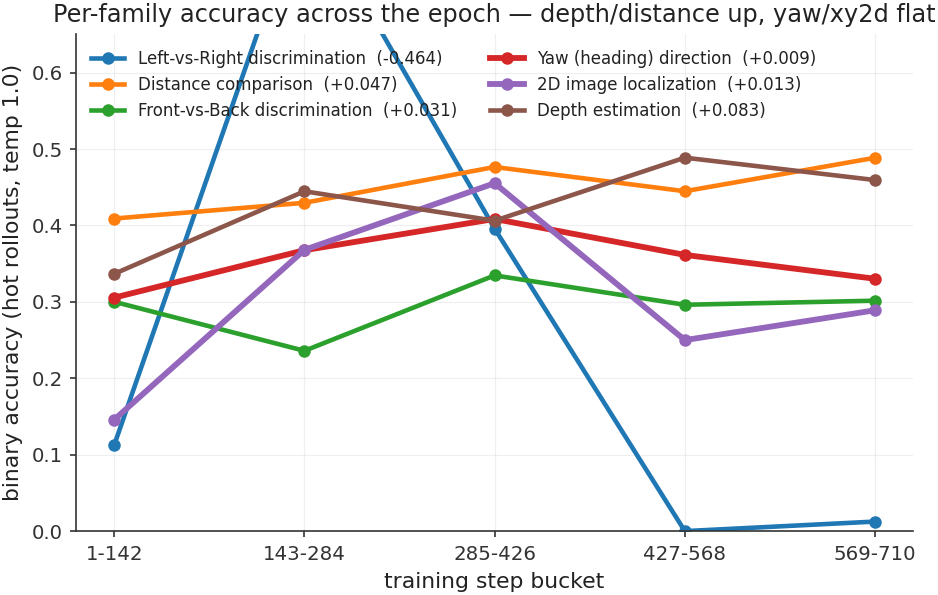

In [2]:
traj = DATA['t1_trajectory']
fams = [t for t in TPL_ORDER if t in traj]
labels = traj[fams[0]]['labels']
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(7.2, 4.3))
for t in fams:
    y = traj[t]['buckets']
    style = dict(marker='o', lw=2.2)
    if t in ('yaw', 'xy2d'):
        style.update(lw=2.8)                       # emphasise the flat dominators
    ax.plot(x, y, label=f"{tname(t)}  ({traj[t]['trend'].split()[0]})",
            color=ps.pretty_template and None, **style)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=0)
ax.set_xlabel('training step bucket'); ax.set_ylabel('binary accuracy (hot rollouts, temp 1.0)')
ax.set_title('Per-family accuracy across the epoch — depth/distance up, yaw/xy2d flat')
ax.set_ylim(0, 0.65); ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, ncol=2, loc='upper left', framealpha=0.9)
ps.savefig(fig, 'grpo_stall_fig1_per_template_trajectory'); plt.show()

In [3]:
# Per-family summary table (share of data, early->late, verdict)
rows = []
for t in TPL_ORDER:
    if t not in traj: continue
    b = traj[t]['buckets']
    rows.append({
        'family': tname(t),
        'rollouts': COUNTS.get(t, 0),
        '% of data': round(100 * COUNTS.get(t, 0) / N_TOT, 1),
        'acc early': round(b[0], 3),
        'acc late': round(b[-1], 3),
        'Δ (early→late)': round(b[-1] - b[0], 3),
        'verdict': traj[t]['trend'].split()[1] if len(traj[t]['trend'].split()) > 1 else '',
    })
df_tpl = pd.DataFrame(rows)
display(Markdown('**Table 1 — per-family trajectory.** `lr` is a single-prompt artifact; '
                 'the real story is depth/distance improving vs yaw/xy2d (62 % of data) flat.'))
display(df_tpl)

**Table 1 — per-family trajectory.** `lr` is a single-prompt artifact; the real story is depth/distance improving vs yaw/xy2d (62 % of data) flat.

,family,rollouts,% of data,acc early,acc late,Δ (early→late),verdict
0,Left-vs-Right discrimination,368,2.0,0.113,0.013,-0.100,DEGRADE
1,Distance comparison,880,4.8,0.409,0.489,0.080,IMPROVE
2,Front-vs-Back discrimination,4864,26.4,0.300,0.302,0.001,IMPROVE
3,Yaw (heading) direction,8784,47.7,0.306,0.330,0.025,FLAT
4,2D image localization,688,3.7,0.146,0.289,0.143,FLAT
5,Depth estimation,2848,15.5,0.337,0.459,0.123,IMPROVE


## 2 · The policy moves a lot — accuracy does not

Twin-axis view over all 710 steps: **binary accuracy is flat** while **KL-divergence from the
SFT reference grows ~40×** (0.003 → 0.13). The optimiser is doing real work (grad-norm bounded
and non-zero), the policy is drifting steadily from SFT — but none of that motion lands on
correctness. This is the signature of *RL sharpening sampling, not adding capability*.

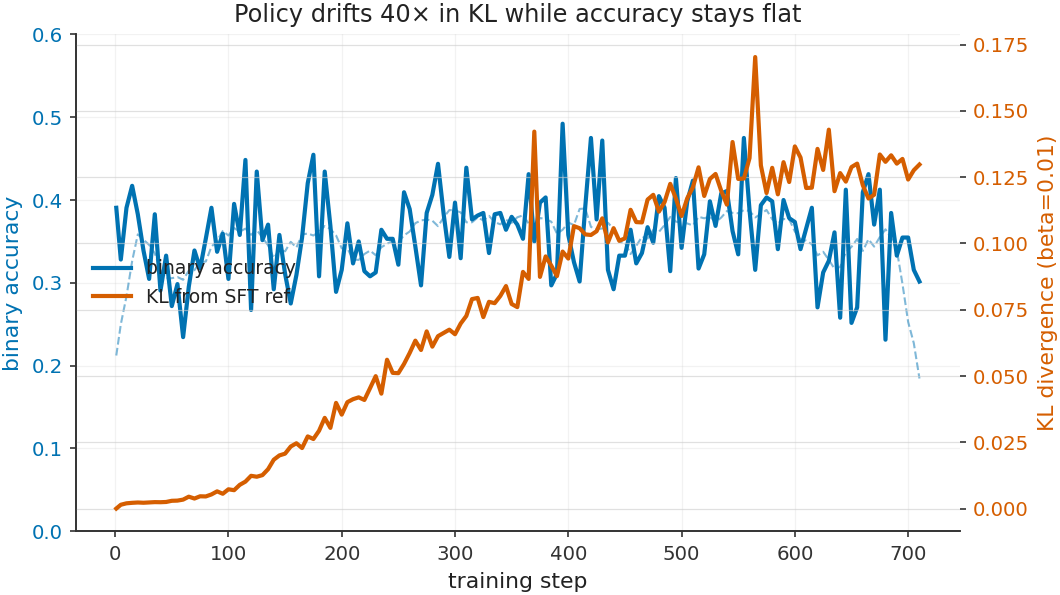

binary accuracy: first10 mean 0.356 -> last10 mean 0.349
KL            : first10 mean 0.0020 -> last10 mean 0.1276  (65x)


In [4]:
tr = DATA['training_trajectory']
step = np.array(tr['step'], float)
binacc = np.array([np.nan if v is None else v for v in tr['binacc']], float)
kl = np.array([np.nan if v is None else v for v in tr['kl']], float)
ln = np.array([np.nan if v is None else v for v in tr['len']], float)

fig, ax1 = plt.subplots(figsize=(7.6, 4.3))
c_acc, c_kl = ps.arm_color('grpo') if hasattr(ps, 'arm_color') else 'C0', 'C3'
l1, = ax1.plot(step, binacc, color='#0072B2', lw=2.0, label='binary accuracy')
# smooth trend
if np.isfinite(binacc).sum() > 10:
    k = np.ones(9) / 9
    sm = np.convolve(np.nan_to_num(binacc, nan=np.nanmean(binacc)), k, 'same')
    ax1.plot(step, sm, color='#0072B2', lw=1.0, alpha=0.5, ls='--')
ax1.set_xlabel('training step'); ax1.set_ylabel('binary accuracy', color='#0072B2')
ax1.set_ylim(0, 0.6); ax1.tick_params(axis='y', labelcolor='#0072B2'); ax1.grid(True, alpha=0.25)
ax2 = ax1.twinx()
l2, = ax2.plot(step, kl, color='#D55E00', lw=2.0, label='KL from SFT ref')
ax2.set_ylabel('KL divergence (beta=0.01)', color='#D55E00')
ax2.tick_params(axis='y', labelcolor='#D55E00')
ax1.set_title('Policy drifts 40× in KL while accuracy stays flat')
ax1.legend(handles=[l1, l2], loc='center left', fontsize=9, framealpha=0.9)
ps.savefig(fig, 'grpo_stall_fig2_training_dynamics'); plt.show()

print(f"binary accuracy: first10 mean {np.nanmean(binacc[:10]):.3f} -> last10 mean {np.nanmean(binacc[-10:]):.3f}")
print(f"KL            : first10 mean {np.nanmean(kl[:10]):.4f} -> last10 mean {np.nanmean(kl[-10:]):.4f}  "
      f"({np.nanmean(kl[-10:])/max(np.nanmean(kl[:10]),1e-6):.0f}x)")

## 3 · It is **not** a zero-gradient problem

A common GRPO failure is degenerate groups (all-16 correct or all-16 wrong → zero advantage →
no gradient). Here **~87 % of prompt-groups are mixed** and carry gradient throughout; the
all-wrong fraction only creeps up late. So the gradient exists — the issue is *what* it
optimises toward, not its absence.

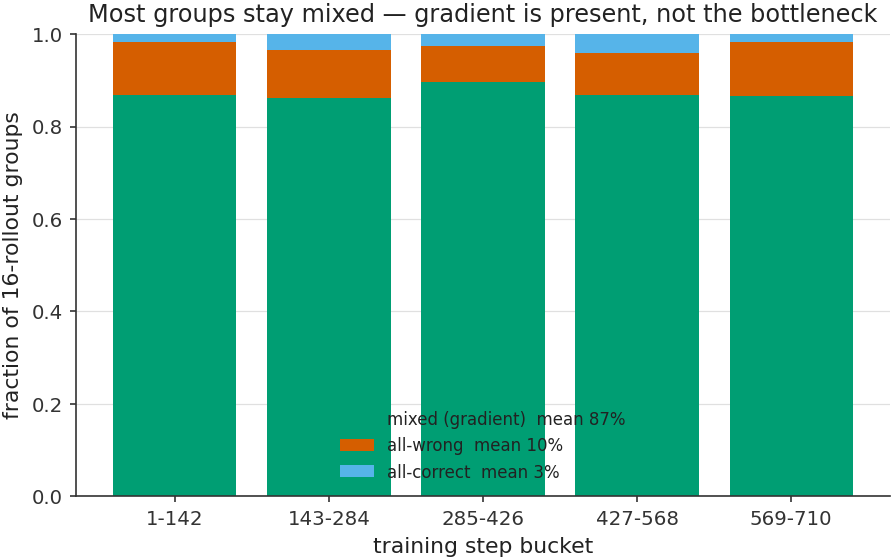

In [5]:
gv = DATA['t1_group_variance']
bs = gv['bucket_stats']; blab = gv['bucket_labels']
keys = sorted(bs.keys(), key=lambda k: int(k))
allc = np.array([bs[k]['all_correct'] / bs[k]['total'] for k in keys])
allw = np.array([bs[k]['all_wrong'] / bs[k]['total'] for k in keys])
mix = np.array([bs[k]['mixed'] / bs[k]['total'] for k in keys])
x = np.arange(len(keys))

fig, ax = plt.subplots(figsize=(7.0, 4.0))
ax.bar(x, mix, color='#009E73', label=f'mixed (gradient)  mean {gv["mixed_frac"]*100:.0f}%')
ax.bar(x, allw, bottom=mix, color='#D55E00', label=f'all-wrong  mean {gv["all_wrong_frac"]*100:.0f}%')
ax.bar(x, allc, bottom=mix + allw, color='#56B4E9', label=f'all-correct  mean {gv["all_correct_frac"]*100:.0f}%')
ax.set_xticks(x); ax.set_xticklabels(blab, rotation=0)
ax.set_xlabel('training step bucket'); ax.set_ylabel('fraction of 16-rollout groups')
ax.set_title('Most groups stay mixed — gradient is present, not the bottleneck')
ax.set_ylim(0, 1); ax.legend(fontsize=8, loc='lower center')
ps.savefig(fig, 'grpo_stall_fig3_group_variance'); plt.show()

## 4 · `xy2d` wrong answers are near-misses (scored in the correct pixel frame)

For `xy2d` and `depth`, how far are **wrong** answers from gold, in units of the pass tolerance?
If the model had partial grounding, wrong answers would cluster *just past* the tolerance
(near-misses). For **`xy2d`** — once scored in the native **pixel** frame (pred rescaled 0–1000→px,
gold is px, tol 50 px) — that is exactly what we see: wrong points sit a **median ≈2× tolerance**
away and about **half of the wrong rollouts** (and ~64 % of *all* rollouts) fall within 2× tol. The
Gaussian dense reward (σ≈50 px) is **active** at that ~100 px error scale. So `xy2d` is a
**consolidation** opportunity (student ≈30 %, 235 B teacher 76 %), not a perceptual void.
**`depth`** wrong answers are broader (median ≈4.5× tol). *(The earlier "xy2d median 8.8× tol /
de-facto binary" panel was a coordinate-FRAME bug — 0–1000 norm pred vs ~1600 px gold; corrected
here per repo `CLAUDE.md` "SURDS xy2d coordinate frames".)*

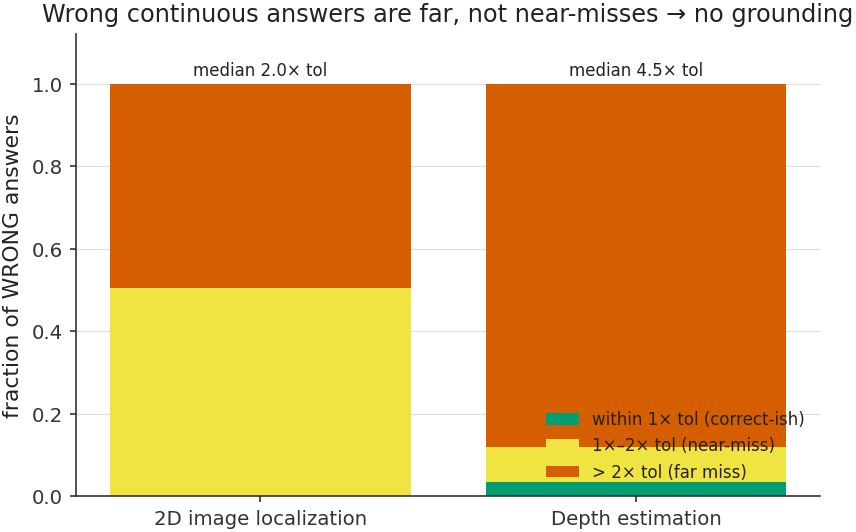

In [6]:
nm = DATA['t1_nearmiss']
fams_c = [f for f in ('xy2d', 'depth') if f in nm]
within1 = [nm[f].get('frac_within_tol', 0) for f in fams_c]
within2 = [nm[f].get('frac_within_2x_tol', 0) for f in fams_c]
band_1x = np.array(within1)
band_12 = np.array(within2) - np.array(within1)
band_gt = 1 - np.array(within2)
x = np.arange(len(fams_c))

fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.bar(x, band_1x, color='#009E73', label='within 1× tol (correct-ish)')
ax.bar(x, band_12, bottom=band_1x, color='#F0E442', label='1×–2× tol (near-miss)')
ax.bar(x, band_gt, bottom=band_1x + band_12, color='#D55E00', label='> 2× tol (far miss)')
for i, f in enumerate(fams_c):
    ax.text(i, 1.02, f"median {nm[f].get('err_over_tol_median', float('nan')):.1f}× tol",
            ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([tname(f) for f in fams_c])
ax.set_ylabel('fraction of WRONG answers'); ax.set_ylim(0, 1.12)
ax.set_title('Wrong continuous answers are far, not near-misses → no grounding')
ax.legend(fontsize=8, loc='lower right')
ps.savefig(fig, 'grpo_stall_fig4_continuous_error'); plt.show()

## 5 · The `yaw` failure is a structural **south-facing perception bias**

`yaw` is ~46 % of the band and the single biggest drag. Wrong answers are not random: the model
systematically over-predicts **southeast/southwest/south**. Three of the four **diagonal** classes
(NE / SW / NW) sit *at or below* the 1/8 = 12.5 % chance line; only **SE** — the very direction the
bias over-predicts — reads high. This is a perception-prior failure, not a difficulty-calibration
mismatch; re-thresholding the band would not fix it, and RFT on yaw "correct" rollouts (mostly the
SE/cardinal lucky hits) would only entrench the bias.

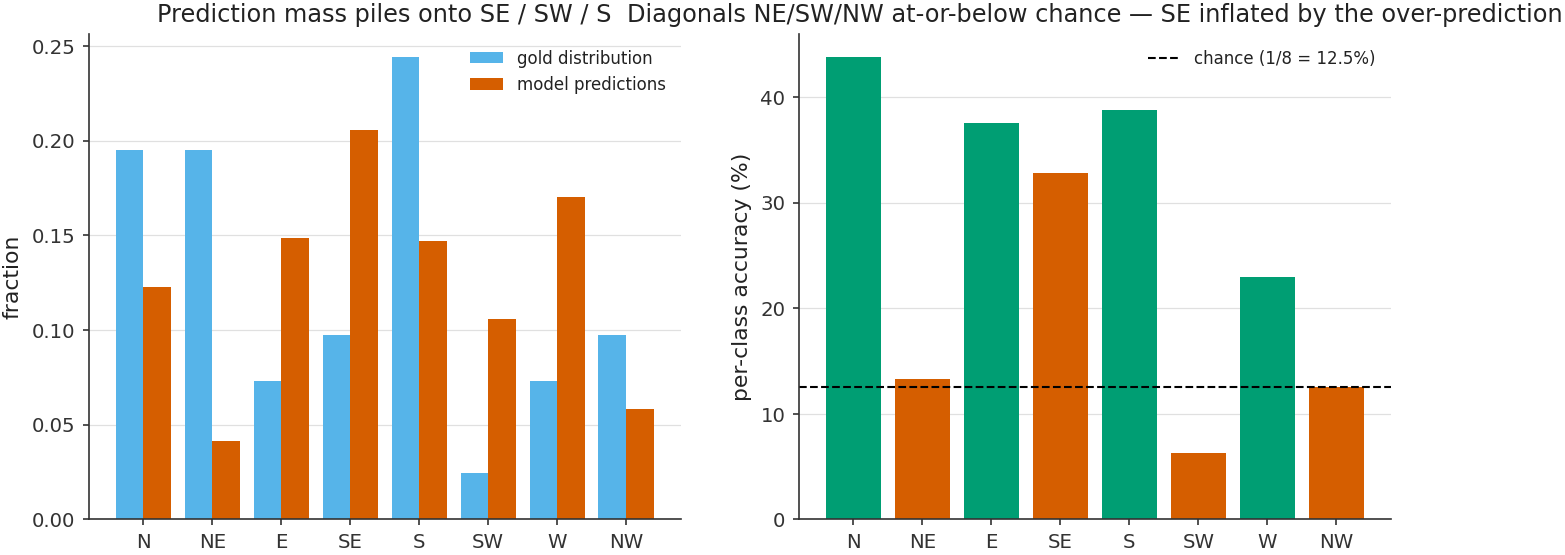

cardinal pred frac: 0.585 | diagonal pred frac: 0.409


In [7]:
COMPASS = ['north','northeast','east','southeast','south','southwest','west','northwest']
ABBR = ['N','NE','E','SE','S','SW','W','NW']
yaw = DATA['t4_yaw']['early']
gd = yaw['gold_dist']; pdist = yaw['pred_dist']; acc = yaw['acc_by_class']
gd_v = np.array([gd.get(c, 0) for c in COMPASS], float); gd_v /= max(gd_v.sum(), 1)
pd_v = np.array([pdist.get(c, 0) for c in COMPASS], float); pd_v /= max(pd_v.sum(), 1)
acc_v = np.array([acc.get(c, 0) for c in COMPASS], float)        # already in %
x = np.arange(len(COMPASS))

fig, (axa, axb) = plt.subplots(1, 2, figsize=(11.2, 4.2))
w = 0.4
axa.bar(x - w/2, gd_v, w, color='#56B4E9', label='gold distribution')
axa.bar(x + w/2, pd_v, w, color='#D55E00', label='model predictions')
axa.set_xticks(x); axa.set_xticklabels(ABBR); axa.set_ylabel('fraction')
axa.set_title('Prediction mass piles onto SE / SW / S'); axa.legend(fontsize=8)
diag = [i for i, c in enumerate(COMPASS) if c in ('northeast','southeast','southwest','northwest')]
bars = axb.bar(x, acc_v, color=['#D55E00' if i in diag else '#009E73' for i in x])
axb.axhline(12.5, color='k', ls='--', lw=1, label='chance (1/8 = 12.5%)')
axb.set_xticks(x); axb.set_xticklabels(ABBR); axb.set_ylabel('per-class accuracy (%)')
axb.set_title('Diagonals NE/SW/NW at-or-below chance — SE inflated by the over-prediction')
axb.legend(fontsize=8)
ps.savefig(fig, 'grpo_stall_fig5_yaw_bias'); plt.show()
print('cardinal pred frac:', round(yaw['cardinal_pred_frac'], 3),
      '| diagonal pred frac:', round(yaw['diagonal_pred_frac'], 3))

## 6 · Per-prompt learnability — `depth` is real headroom, `yaw` is polarising

For each prompt (a group of 16 rollouts), how many came out correct? A spread distribution =
learnable (GRPO has a gradient to sharpen). A bimodal 0/16-or-16/16 distribution = all-or-nothing
(little to learn). Overall the band is learnable, but split by family: `depth` is genuine
mid-range headroom while `yaw` is more bimodal and **worsens** (bimodal 32 %→41 %) as RL entrenches
the prior.

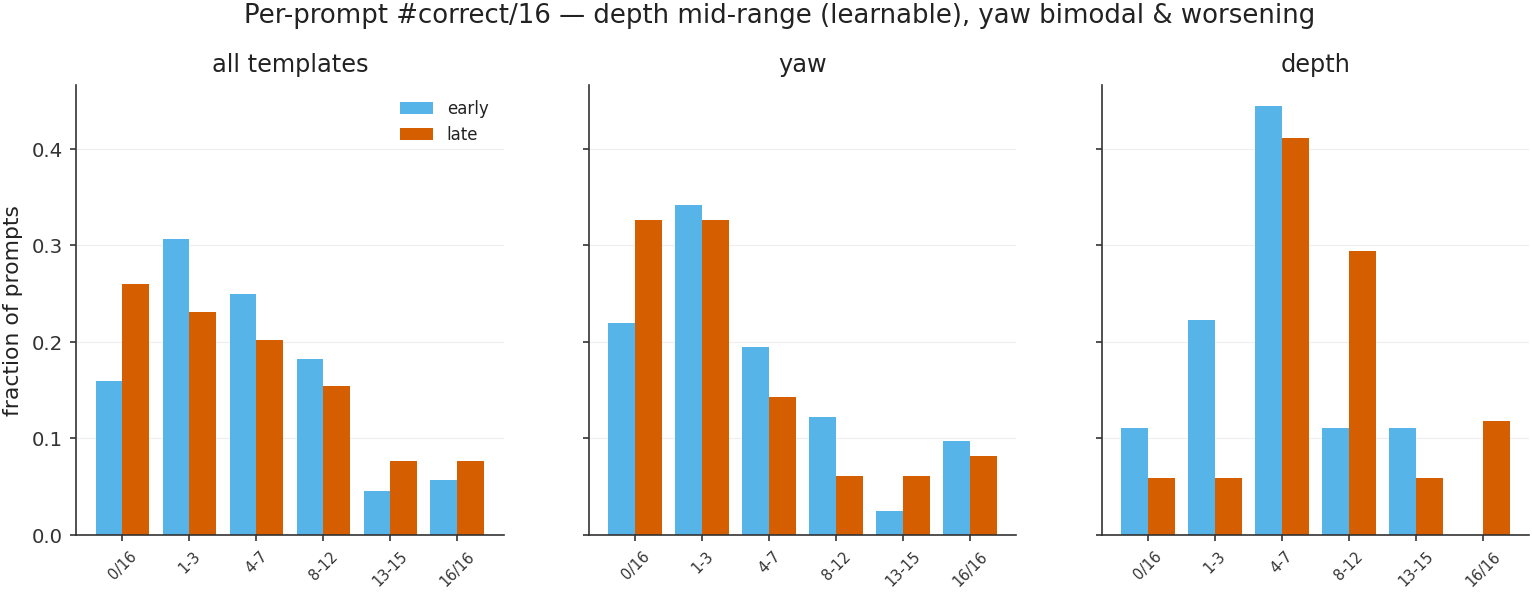

In [8]:
BINS = ['0/16','1-3','4-7','8-12','13-15','16/16']
H = DATA['t4_histograms']
def vec(block):
    b = block['bins']; tot = sum(b.values()) or 1
    return np.array([b.get(k, 0) for k in BINS], float) / tot

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.9), sharey=True)
panels = [('all templates', H['early_all'], H['late_all']),
          ('yaw',  H['early_per_template'].get('yaw', {'bins':{}}),  H['late_per_template'].get('yaw', {'bins':{}})),
          ('depth', H['early_per_template'].get('depth', {'bins':{}}), H['late_per_template'].get('depth', {'bins':{}}))]
x = np.arange(len(BINS)); w = 0.4
for ax, (title, e, l) in zip(axes, panels):
    ax.bar(x - w/2, vec(e), w, color='#56B4E9', label='early')
    ax.bar(x + w/2, vec(l), w, color='#D55E00', label='late')
    ax.set_xticks(x); ax.set_xticklabels(BINS, rotation=45, fontsize=7)
    ax.set_title(title); ax.grid(True, axis='y', alpha=0.3)
axes[0].set_ylabel('fraction of prompts'); axes[0].legend(fontsize=8)
fig.suptitle('Per-prompt #correct/16 — depth mid-range (learnable), yaw bimodal & worsening', y=1.02)
ps.savefig(fig, 'grpo_stall_fig6_passrate_hist'); plt.show()

## 7 · Example rollouts

Concrete rollouts pulled from the run (`completions.jsonl`). They show the regimes directly:
**depth** consolidating (the model *can* do it), **`xy2d`** missing by a near-miss margin (a
real point, slightly off), and **`yaw`** failing perceptually (axis mirror-flip).

In [9]:
ex = DATA['examples']

def show_ex(title, body):
    display(Markdown(f"#### {title}\n\n{body}"))

d = ex.get('depth_mixed')
if d:
    show_ex('depth — same prompt, both a CORRECT and a WRONG rollout (capability present → sharpenable)',
        f"**Gold:** `{d['gold']}`\n\n"
        f"✅ **Correct rollout** → `{d['correct_pred']}`  \n> {d['correct_think']}\n\n"
        f"❌ **Wrong rollout** → `{d['wrong_pred']}` (close — a near-miss)  \n> {d['wrong_think']}")

y = ex.get('yaw_southbias')
if y:
    show_ex('yaw — south-facing bias (gold diagonal, model predicts a southern direction)',
        f"**Gold:** `{y['gold']}`  →  ❌ **Predicted:** `{y['pred']}`\n\n> {y['think']}")

xx = ex.get('xy2d_miss')
if xx:
    show_ex('xy2d — near-miss (predicted point close to gold in pixel space, just past tolerance)',
        f"**Gold point (px):** `{xx['gold']}`  →  ❌ **Predicted (0–1000 norm):** `{xx['pred']}`  "
        f"(L2 ≈ {xx['l2_px']} px = {xx['over_tol']}× the 50 px tolerance, pred rescaled to pixels)"
        f"\n\n> {xx['think']}")

#### depth — same prompt, both a CORRECT and a WRONG rollout (capability present → sharpenable)

**Gold:** `Between 35 meters and 42 meters`

✅ **Correct rollout** → `Between 35 meters and 42 meters`  
> The black car is visible in the middle lane, ahead of the camera. To estimate its vertical distance, I analyze visual cues such as the car’s size relative to the road markings, perspective, and depth cues.

1. The road features dashed white lines and arrows that provide a sense of scale. The car is positioned beyond th …

❌ **Wrong rollout** → `Between 30 meters and 33 meters` (close — a near-miss)  
> The black car is visible in the middle of the road, ahead of the camera. To estimate its vertical distance, I analyze visual cues such as the car’s size relative to the road markings, perspective, and depth cues.

1. The road has lane markings and arrows that provide scale. The car is positioned beyond the immediate ro …

#### yaw — south-facing bias (gold diagonal, model predicts a southern direction)

**Gold:** `Northeast`  →  ❌ **Predicted:** `Southwest`

> The camera is facing South, so the direction the camera is pointing (toward the bottom of the image) is South. The white car is on the left side of the image, positioned on the road. To determine its facing direction, observe the car's orientation relative to the camera's South-facing view. The car is angled such that  …

#### xy2d — near-miss (predicted point close to gold in pixel space, just past tolerance)

**Gold point (px):** `[157, 419]`  →  ❌ **Predicted (0–1000 norm):** `[50, 450]`  (L2 ≈ 78.3 px = 1.57× the 50 px tolerance, pred rescaled to pixels)

> The question asks for the location of the white truck in the image. First, I need to identify which object corresponds to the "white truck." Looking at the scene, there is a large white vehicle on the left side of the image, which appears to be a truck. Additionally, there is a white USPS truck nearby. However, the que …

## 8 · Root-cause ranking (theory leaf T3)

How much each mechanism explains *these specific numbers*. The dominant cause is the **`yaw`
perception capability gap** (axis mirror-flip) that RL cannot fill; **`xy2d` is a consolidation
target** (near-miss, teacher 76 %) reachable by teacher distillation, *not* a perceptual void.

In [10]:
rc = DATA['root_causes']
df_rc = pd.DataFrame(rc, columns=['root cause', 'explanatory share (%)', 'why'])
display(df_rc.style.hide(axis='index').bar(subset=['explanatory share (%)'], color='#cfe8df')
        if hasattr(df_rc, 'style') else df_rc)

root cause,explanatory share (%),why
yaw perception capability gap (axis mirror-flip),45,"yaw (~46% of L2) is an axis mirror-flip ambiguity (E->W 50%, NE->SE 65%): the model gets the orientation axis, wrong sign. RL only sharpens present capability, so it reshuffles a wrong perceptual prior -> flat yaw acc + 40x KL drift. This is the real unsharpenable family and it dominates the average."
"xy2d is a CONSOLIDATION target, not a capability gap",20,"Corrected (was 'capability absent / reward inactive'): in PIXEL space wrong points are a median 1.98x tol out (not 8.8x) and ~64% of rollouts fall within 2x tol = NEAR-MISS; student greedy ~30%, the 235B teacher is 76%, and the Gaussian dense reward (sigma~50px) is ACTIVE at ~100px error. xy2d belongs with depth/distance (latent, distillable), not with yaw. The earlier 'random / reward de-facto inactive' read was a coord-FRAME bug."
Credit dilution + long-CoT attention tax,15,Outcome reward spread over long CoT; long CoT reduces visual-token attention.
On-policy / exploration limits,12,"num_iterations=1, clip inert, temp-1.0-only exploration -> no pressure to discover new grounding."
Data/band weighting (yaw=46%),8,Aggregate dominated by the unsharpenable yaw family; depth +8.3pp / distance +4.7pp gains get averaged away. Down-weighting yaw surfaces the real per-family progress.


## 9 · Why "just RFT everything" fails (red-team leaf T6)

Self-distillation (RFT) on the model's *own* correct rollouts is the obvious move given high
pass@16 — but the harvest is **70 % yaw+fb**, and the `yaw` "correct" rollouts are the mirror-flip
getting lucky (per-class NE 7.7 % / NW 10.7 %, *below* chance). RFT on them would **entrench** the
bias. So self-RFT is only safe **restricted to depth/distance/fb** (yaw class-balanced or excluded).
`xy2d` self-RFT is thin (only ~16 usable self-correct prompts in this band) — but that is *not* the
ceiling: the **235 B teacher is 76 %** on `xy2d`, so `xy2d` is consolidated via **teacher
distillation** (a large correct-trace pool), not self-RFT.

In [11]:
ry = DATA['rft_yield']
df_rft = pd.DataFrame(ry['rows'], columns=ry['header'])
df_rft['harvest yield %'] = (100 * df_rft['prompts_with_correct'] / df_rft['prompts_total']).round(0)
display(Markdown('**Table 3 — RFT harvest yield per family.** ' + ry['note']))
display(df_rft)

**Table 3 — RFT harvest yield per family.** yaw correct rollouts are south-bias luck (NE 7.7% / NW 10.7% per-class, below 12.5% chance) — RFT on them would entrench the bias. yaw+fb = ~70% of harvest.

,family,prompts_with_correct,prompts_total,unique_correct_cots,harvest yield %
0,yaw,363,430,2934,84.0
1,fb,163,206,1417,79.0
2,depth+distance,215,224,1591,96.0
3,xy2d,16,20,202,80.0
4,lr,10,21,101,48.0


## 10 · Solution plan (synthesis T5 + red-team T6)

Cheapest/safest first. The near-free **GATE** re-baselines every claim and routes the next GPU
node correctly; **teacher-distillation consolidation SFT** for `xy2d`+`yaw` (job `pretrain_model_35`,
in flight) is the highest-ROI *training* move; the **`yaw` perception track** is the only thing that
raises the genuine capability ceiling.

In [12]:
sp = DATA['solution_plan']
df_sp = pd.DataFrame(sp, columns=['rank', 'action', 'mechanism', 'cost (8×H200, 1 node)', 'priority'])
display(df_sp)
display(Markdown(
    '### Reading the verdict\n'
    '- **GRPO is not broken** — it sharpened depth (+8.3 pp) and distance (+4.7 pp). The flat '
    'headline was yaw (≈46 %) + xy2d, which are **perception-capped**, averaging the gains away.\n'
    '- **No reward / beta / lr knob fixes a missing perceptual capability.** That needs grounding '
    'data, a perception-friendlier base (Instruct / shorter CoT), or tool-use (crop-zoom).\n'
    '- **Do the free GATE first** (frozen-SFT per-family pass@1 vs pass@16 on held-out, cardinal vs '
    'diagonal yaw split, train/val leakage check, re-baseline vs 0.6583), *then* spend GPU on '
    'restricted RFT for the capability-present families.'))

,rank,action,mechanism,"cost (8×H200, 1 node)",priority
0,1,"GATE: frozen-SFT per-template pass@1 vs pass@16 (held-out, greedy+n16, cardinal/diagonal yaw split, leakage check, re-baseline vs greedy SFT)",discriminate exploitable vs capability-capped,~1 GPU-hr,"near-free, do first"
1,2,"Teacher-distillation consolidation SFT for xy2d + yaw: harvest 235B-teacher-CORRECT pixel-frame xy2d (76%) and class-balanced yaw traces, continue-SFT from ...",lift xy2d near-miss -> hit (teacher 76% >> student 30%) and rebalance yaw classes,~1 day 8xGPU,highest-ROI move (in flight)
2,3,"RFT self-distillation for depth/distance/fb (latent, pass@16>>pass@1)",consolidate present capability cheaply,~4-6 GPU-hr,supporting
3,4,Curriculum re-weight: down-weight yaw so depth/distance/xy2d gains aren't averaged away,efficiency / stop yaw averaging-down,free split,supporting
4,5,"yaw perception track: audit teacher diagonal-yaw (NE/NW flip is shared), crop-zoom tool-use, try Instruct base",raise the yaw CEILING (the one genuine capability gap),8-16 GPU-hr,separate track


### Reading the verdict
- **GRPO is not broken** — it sharpened depth (+8.3 pp) and distance (+4.7 pp). The flat headline was yaw (≈46 %) + xy2d, which are **perception-capped**, averaging the gains away.
- **No reward / beta / lr knob fixes a missing perceptual capability.** That needs grounding data, a perception-friendlier base (Instruct / shorter CoT), or tool-use (crop-zoom).
- **Do the free GATE first** (frozen-SFT per-family pass@1 vs pass@16 on held-out, cardinal vs diagonal yaw split, train/val leakage check, re-baseline vs 0.6583), *then* spend GPU on restricted RFT for the capability-present families.